# 236. Lowest Common Ancestor of a Binary Tree
https://leetcode.com/problems/lowest-common-ancestor-of-a-binary-tree/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Path Finding | O(n) | O(n) | Store paths from root to p and q, compare |
| **Recursive DFS** | **O(n)** | **O(h)** | **Post-order traversal, bubble up matches** |
| Iterative with Parent | O(n) | O(n) | BFS to build parent map, then trace ancestors |

## Methodology

We use **recursive post-order DFS**. For each node, we recursively check the left and right subtrees. If a node is `p` or `q`, we return it. If both left and right recursive calls return non-null, the current node is the LCA. Otherwise, we propagate whichever side returned non-null. This elegantly finds the LCA in a single O(n) traversal.

## Solutions

### C#

In [ ]:
// 236. Lowest Common Ancestor of a Binary Tree
// Time: O(n) | Space: O(h)
public class TreeNode {
    public int val;
    public TreeNode left;
    public TreeNode right;
    public TreeNode(int x) { val = x; }
}

public class Solution {
    public TreeNode LowestCommonAncestor(TreeNode root, TreeNode p, TreeNode q) {
        if (root == null || root == p || root == q) return root;
        
        TreeNode left = LowestCommonAncestor(root.left, p, q);
        TreeNode right = LowestCommonAncestor(root.right, p, q);
        
        if (left != null && right != null) return root;
        return left ?? right;
    }
}

### Python

In [ ]:
# 236. Lowest Common Ancestor of a Binary Tree
# Time: O(n) | Space: O(h)
class TreeNode:
    def __init__(self, x):
        self.val = x
        self.left = None
        self.right = None

class Solution:
    def lowestCommonAncestor(self, root: TreeNode, p: TreeNode, q: TreeNode) -> TreeNode:
        if not root or root == p or root == q:
            return root
        
        left = self.lowestCommonAncestor(root.left, p, q)
        right = self.lowestCommonAncestor(root.right, p, q)
        
        if left and right:
            return root
        return left or right

### Go

In [ ]:
// 236. Lowest Common Ancestor of a Binary Tree
// Time: O(n) | Space: O(h)
type TreeNode struct {
    Val   int
    Left  *TreeNode
    Right *TreeNode
}

func lowestCommonAncestor(root, p, q *TreeNode) *TreeNode {
    if root == nil || root == p || root == q {
        return root
    }
    
    left := lowestCommonAncestor(root.Left, p, q)
    right := lowestCommonAncestor(root.Right, p, q)
    
    if left != nil && right != nil {
        return root
    }
    if left != nil {
        return left
    }
    return right
}

### Rust

In [ ]:
// 236. Lowest Common Ancestor of a Binary Tree
// Time: O(n) | Space: O(h)
use std::rc::Rc;
use std::cell::RefCell;

#[derive(Debug, PartialEq, Eq)]
pub struct TreeNode {
    pub val: i32,
    pub left: Option<Rc<RefCell<TreeNode>>>,
    pub right: Option<Rc<RefCell<TreeNode>>>,
}

impl Solution {
    pub fn lowest_common_ancestor(
        root: Option<Rc<RefCell<TreeNode>>>,
        p: Option<Rc<RefCell<TreeNode>>>,
        q: Option<Rc<RefCell<TreeNode>>>,
    ) -> Option<Rc<RefCell<TreeNode>>> {
        let pv = p.as_ref().unwrap().borrow().val;
        let qv = q.as_ref().unwrap().borrow().val;
        Self::dfs(&root, pv, qv)
    }
    
    fn dfs(node: &Option<Rc<RefCell<TreeNode>>>, pv: i32, qv: i32) -> Option<Rc<RefCell<TreeNode>>> {
        match node {
            None => None,
            Some(n) => {
                let val = n.borrow().val;
                if val == pv || val == qv {
                    return Some(n.clone());
                }
                let left = Self::dfs(&n.borrow().left, pv, qv);
                let right = Self::dfs(&n.borrow().right, pv, qv);
                if left.is_some() && right.is_some() {
                    Some(n.clone())
                } else {
                    left.or(right)
                }
            }
        }
    }
}

## Example Scenarios

### 1. Common Case — LCA at Root
**Input:** Tree `[3,5,1,6,2,0,8]`, `p = 5`, `q = 1`

Node 5 is found in the left subtree, node 1 in the right subtree. Since both sides return non-null, the root `3` is the LCA.

### 2. Slightly Complex — LCA Is an Ancestor of the Other
**Input:** Tree `[3,5,1,6,2,0,8,null,null,7,4]`, `p = 5`, `q = 4`

Node 4 is a descendant of node 5 (right $\to$ right). The recursion finds 5 first and returns it upward; the right subtree returns null. So LCA is `5` — a node can be its own ancestor.

### 3. Edge Case: Time Factor — Linear Chain Tree
**Input:** Tree is a left-skewed chain of $n = 10{,}000$ nodes, `p = \text{node at depth } 9998`, `q = \text{leaf}`

The DFS must visit all $n$ nodes since $p$ and $q$ sit at the very bottom. Time is $O(n) = 10{,}000$ node visits, the worst-case scenario for this algorithm.

### 4. Edge Case: Space Factor — Recursion Depth Equals Tree Height
**Input:** Fully left-skewed tree with $10^4$ nodes, `p` and `q` are the last two nodes

Recursion depth hits $O(n)$, consuming $O(n)$ stack frames. For a balanced tree of the same size, stack depth would be only $O(\log n) \approx 14$ frames. The shape of the tree directly determines memory usage.

### 5. Almost-Impossible but Plausible — Two-Node Tree
**Input:** Tree `[1,2]`, `p = 1`, `q = 2`

The smallest valid input under the constraint $n \ge 2$. Root `1` equals $p$, so the left subtree call finds $q = 2$. Since `1` matches $p$, it returns immediately — the root `1` is the LCA in $O(1)$ time.

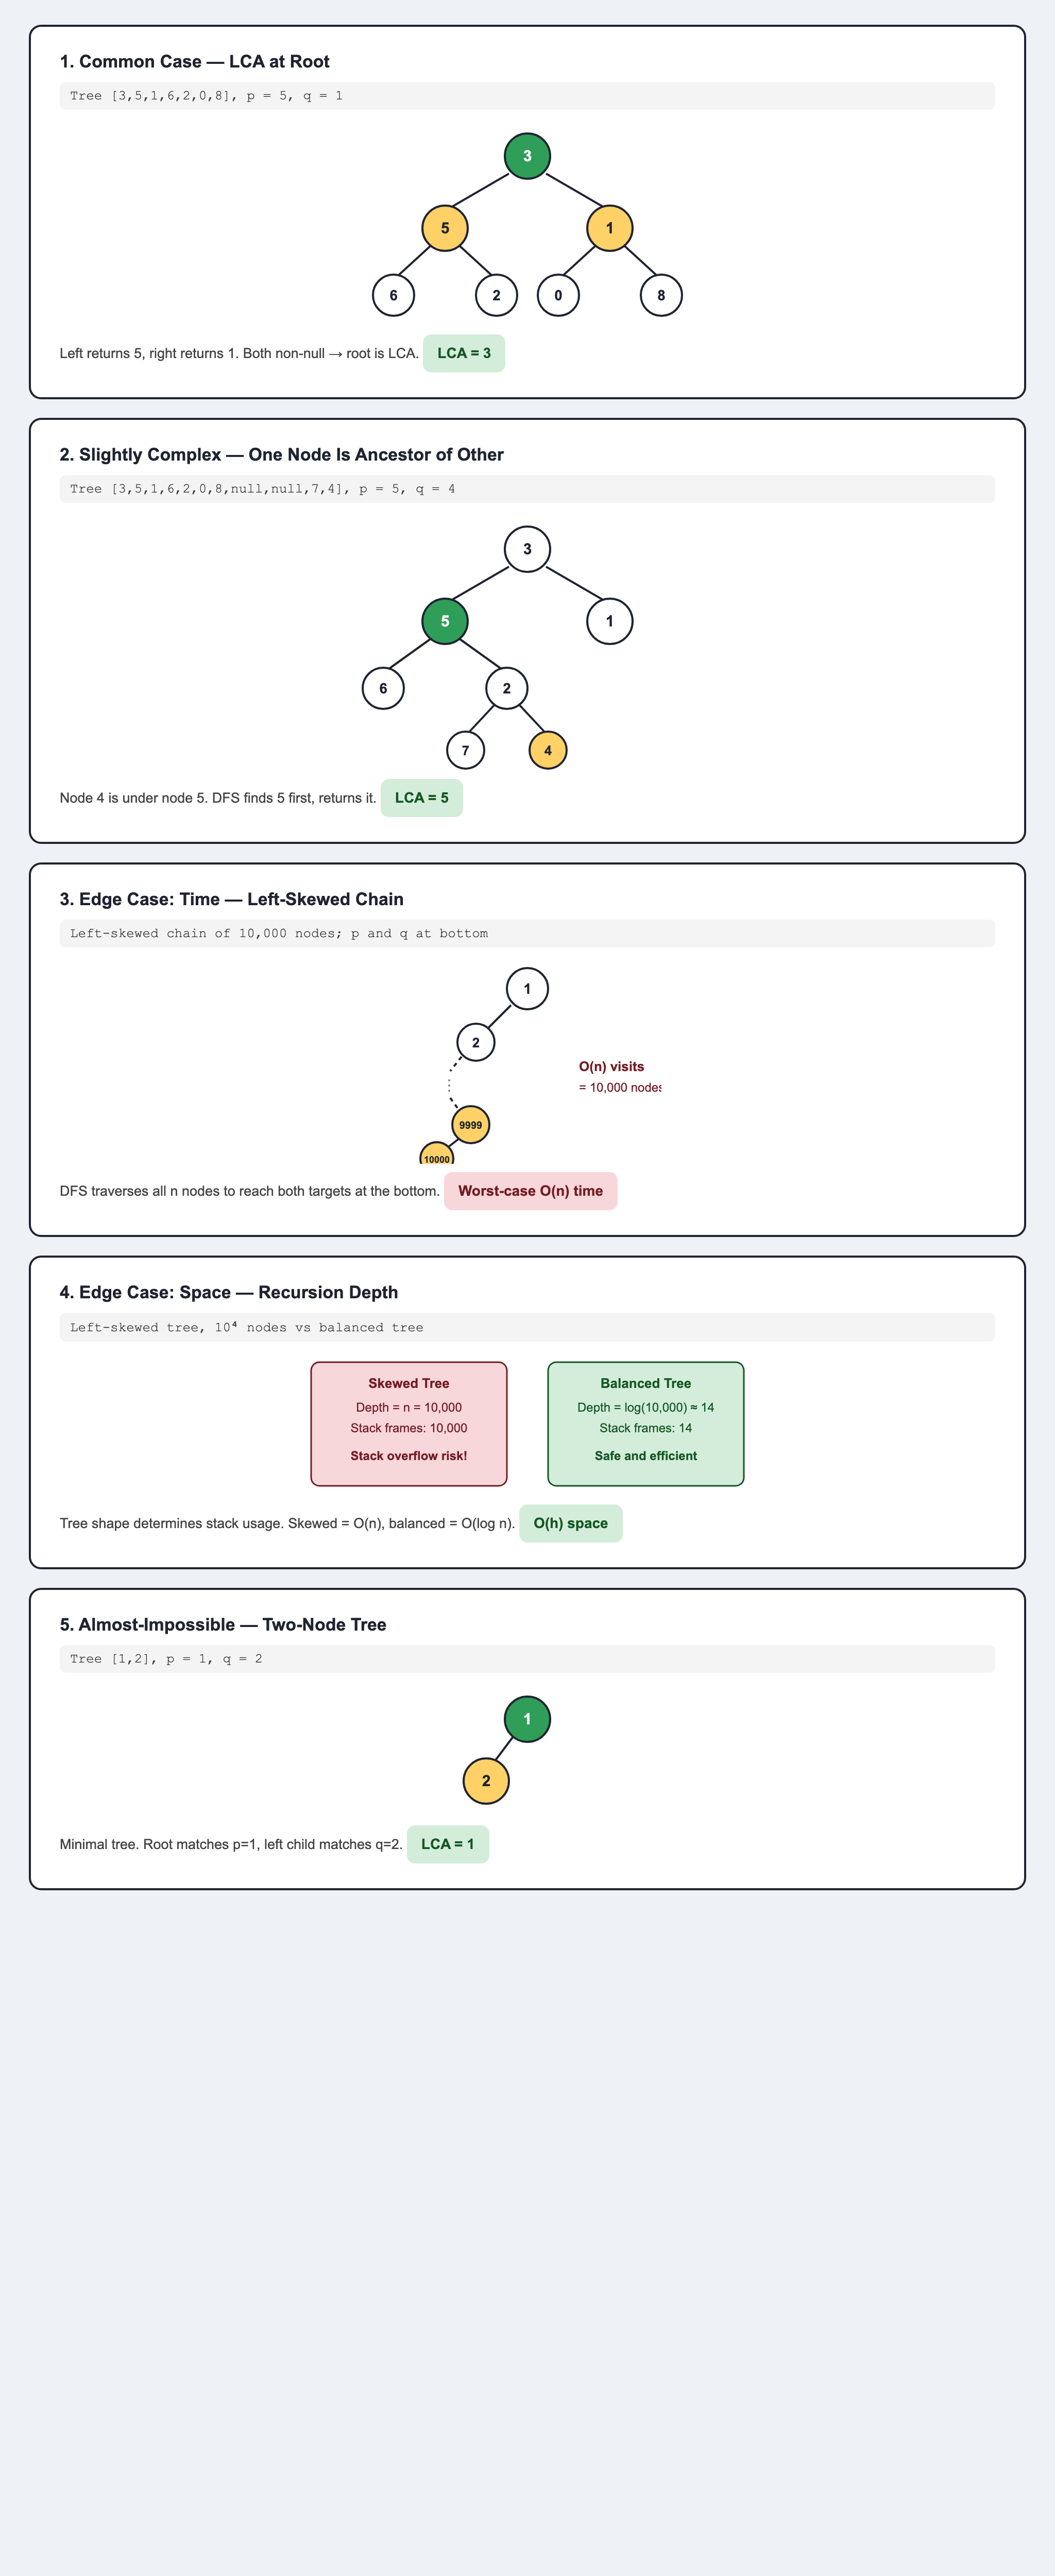